In [1]:
# INSERT ALL NEEDED LIBRARIES
using Distributions
using Random
using SpecialFunctions
using Plots
using OffsetArrays
using LaTeXStrings
using Interpolations
using Base.Threads
using GSL
using QuadGK


Threads.nthreads()

1

$$
    dX_t = -\dfrac{\kappa(t)}{\gamma} X_t dt + \sqrt{\dfrac{2 k_BT(t)}{\gamma}} dW_t
$$

Let 
$$ 
A \equiv \dfrac{\gamma}{2k_BT(0)}
$$

$$
\omega(t) \equiv \dfrac{\kappa(t)}{\gamma}
$$

$$
\Omega(t) = \int_{0}^{t} \omega(s) ds
$$

\begin{equation}
    \tilde{\tau}(t) = \int_{0}^{t} e^{-2(\Omega(t)-\Omega(s))} ds.
\end{equation}

If the temperature is constant over time the solution reads
\begin{equation}
    \wp(0,t|x_0) = \sqrt{A} \dfrac{|x_0| e^{-\Omega(t)}}{\sqrt{2\pi \tilde{\tau}^3(t)}} \exp \left(- A \dfrac{x_0^2 e^{-2\Omega(t)}}{2 \tilde{\tau}(t)} \right)
\end{equation}

# Initialize functions according to the chosen stiffness protocol

In [2]:
function initialize_ω(mode::String, t)
    if mode=="Constant"
        return ω_0
    elseif mode=="Linear"
        return ω_0 + ω_1*t
    elseif mode=="Quadratic"
        return ω_0 + ω_1*t + ω_2*t^2
    else
        return 0.0
    end
end

initialize_ω (generic function with 1 method)

In [3]:
function initialize_Ω(mode::String, t)
    if mode=="Constant"
        return ω_0*t
    elseif mode=="Linear"
        return ω_0*t + (1/2)*ω_1*t^2
    elseif mode=="Quadratic"
        return ω_0*t + (1/2)*ω_1*t^2 + (1/3)*ω_2*t^3
    else
        return 0.0
    end
end

initialize_Ω (generic function with 1 method)

In [4]:
function initialize_τ(mode::String, t)
    if mode=="Constant"
        return (1-exp(-2*Ω(t)))/2/ω(t)
    elseif mode=="Linear"
        return (1/√(ω_1)) *( (dawson(ω(t)/√(ω_1))) - exp(-2*Ω(t))*dawson(ω_0/√(ω_1)) )  # ω_1 cannot be set to 0!!!!
    elseif mode=="Quadratic"
        t_step = t/Nsteps
        t_support = 0.0:t_step:1.2*t
        τ_space = zeros(Float64, length(t_support))
        integrand(s) = exp(-2*(Ω(t)-Ω(s)))
        for (i, s) in enumerate(t_support)
            τ_space[i] = quadgk(integrand, 0.0, s, rtol=1e-8)[1]
        end
        dummy_function = cubic_spline_interpolation(t_support, τ_space)
        return dummy_function(t)
    else
        return 1.0
    end
end

initialize_τ (generic function with 1 method)

In [5]:
ω(t) = initialize_ω(control_string, t)
Ω(t) = initialize_Ω(control_string, t)
τ(t) = initialize_τ(control_string, t)
℘(t, x_0) = √(A)* abs(x_0)*exp(-Ω(t))/√(2*π*(τ(t))^3) * exp(-A*(x_0^2*exp(-2*Ω(t)))/(2*τ(t)))

℘ (generic function with 1 method)

# Simulations for constant, linear and quadratic stiffness

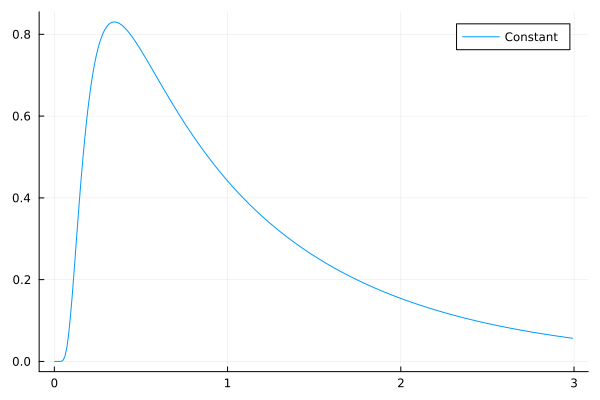

In [7]:
A = 1.0
x_0 = 1.0
ω_0 = 1.0
ω_1 = 1.0
ω_2 = 1.0
Nsteps = 10^3 # Needed only for the quadratic case

control_string = "Constant"

total_time = 3.0
t_space = collect(0.002:0.01:total_time)

plot(t_space, ℘.(t_space, x_0), label=control_string)

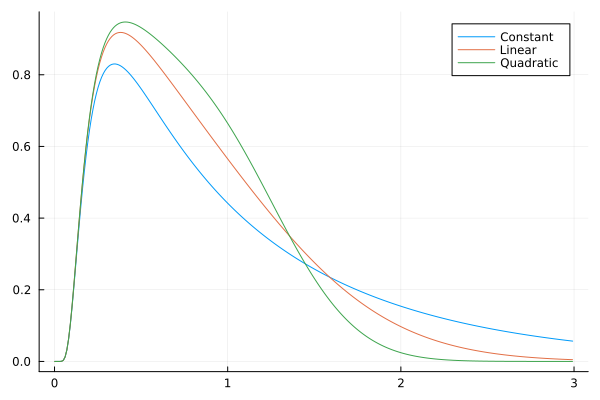

In [10]:
control_string = "Quadratic"
t_space = collect(0.001:0.01:3.0)
plot!(t_space, ℘.(t_space, x_0), label=control_string)

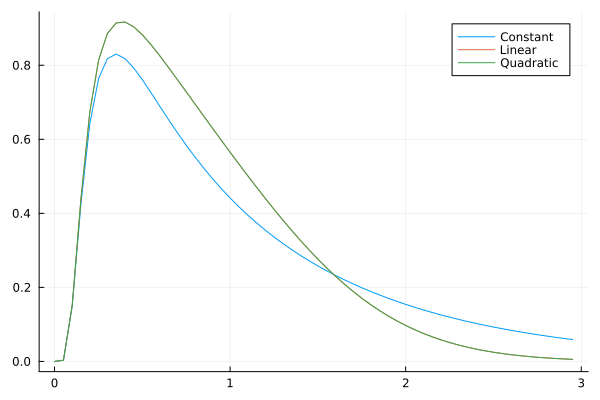

In [9]:
control_string = "Quadratic"
ω_2 = 0.0  # If this is 0 linear and quadratic match
plot!(t_space, ℘.(t_space, x_0), label=control_string)

# Commands for the script

In [10]:
print("Welcome, this script will help you plotting the distribution of the first passage in the interval [0,t].\n
    First of all, please enter the value of t ")
total_time = parse(Float64, readline())
print("The interval [0,t] is discretized in N small steps. Please enter the value of N ")
N = parse(Float64, readline())
t_step = total_time/N
t_space = collect(0.001:t_step:total_time)

print("Please enter the value of the parameter A≡γ/2k_BT. A = ")
A = parse(Float64, readline())
print("Please enter the value of the initial position x_0 ")
x_0 = parse(Float64, readline())
print("Let us define the frequency ω(t)=κ(t)/γ, i.e. the stiffness divided by the friction.\n
    You can choose between 'Constant', 'Linear' and 'Quadratic' protocol. \n Enter the protocol desired ")
control_string = readline()
if control_string == "Constant"
    print("Then your frequency is ω(t)=ω_0. Please enter ω_0 ")
    ω_0 = parse(Float64, readline())
elseif control_string == "Linear"
    print("Then your frequency is ω(t)=ω_0+ω_1*t. Please enter ω_0 ")
    ω_0 = parse(Float64, readline())
    print("Please enter ω_1 ")
    ω_1 = parse(Float64, readline())
elseif control_string == "Quadratic"
    print("Then your frequency is ω(t)=ω_0+ω_1*t+ω_2*t*t. Please enter ω_0 ")
    ω_0 = parse(Float64, readline())
    print("Please enter ω_1 ")
    ω_1 = parse(Float64, readline())
    print("Please enter ω_2 ")
    ω_2 = parse(Float64, readline())
else
    print("Wrong entry. Run the program again")
end
if control_string == "Constant" || control_string == "Linear" || control_string == "Quadratic"
    ω(t) = initialize_ω(control_string, t)
    Ω(t) = initialize_Ω(control_string, t)
    τ(t) = initialize_τ(control_string, t)
    ℘(t, x_0) = √(A)* abs(x_0)*exp(-Ω(t))/√(2*π*(τ(t))^3) * exp(-A*(x_0^2*exp(-2*Ω(t)))/(2*τ(t)))
    FPTD_vector = ℘.(t_space, x_0)

    open(string("FPTD_Analytical_", control_string, "_", string(x_0), "_", string(A), ".txt"), "w") do io
        write(io, string("Parameters: ", control_string, " protocol, x_0=", string(x_0), ", t=", string(total_time), ", A=", 
                string(A), "\n"))
        write(io, "time axis                            first-passage time distribution \n")
        for i=1:length(t_space)
            write(io, string(string(t_space[i]), "                                  ", string(FPTD_vector[i]), "\n"))
        end
    end
end

Welcome, this script will help you plotting the distribution of the first passage in the interval [0,t].

    First of all, please enter the value of t stdin> 3.0
The interval [0,t] is discretized in N small steps. Please enter the value of N stdin> 1000
Please enter the value of the parameter A≡γ/2k_BT. A = stdin> 1.0
Please enter the value of the initial position x_0 stdin> 1.0
Let us define the frequency ω(t)=κ(t)/γ, i.e. the stiffness divided by the friction.

    You can choose between 'Constant', 'Linear' and 'Quadratic' protocol. 
 Enter the protocol desired stdin> Constant
Then your frequency is ω(t)=ω_0. Please enter ω_0 stdin> 1.0


In [8]:
total_time = 3.0
FPTD_vector = ℘.(t_space, x_0)
file_path = joinpath("C:\\Users\\Costantino\\Desktop\\Dan_scripts", 
    string("FPTD_Analytical_", control_string, "_", string(x_0), "_", string(A), ".txt"))

open(file_path, "w") do io
    write(io, string("Parameters: ", control_string, " protocol, x_0=", string(x_0), ", t=", string(total_time), ", A=", 
            string(A), "\n"))
    write(io, "time axis                            first-passage time distribution \n")
    for i=1:length(t_space)
        write(io, string(string(t_space[i]), "                                  ", string(FPTD_vector[i]), "\n"))
    end
end

# Commands for the script 2

In [9]:
total_time = parse(Float64, readline())
N = parse(Float64, readline())
t_step = total_time/N
t_space = collect(0.001:t_step:total_time)

A = parse(Float64, readline())
x_0 = parse(Float64, readline())
control_string = readline()
if control_string == "Constant"
    print("Then your frequency is ω(t)=ω_0. Please enter ω_0 ")
    ω_0 = parse(Float64, readline())
elseif control_string == "Linear"
    print("Then your frequency is ω(t)=ω_0+ω_1*t. Please enter ω_0 ")
    ω_0 = parse(Float64, readline())
    print("Please enter ω_1 ")
    ω_1 = parse(Float64, readline())
elseif control_string == "Quadratic"
    print("Then your frequency is ω(t)=ω_0+ω_1*t+ω_2*t*t. Please enter ω_0 ")
    ω_0 = parse(Float64, readline())
    print("Please enter ω_1 ")
    ω_1 = parse(Float64, readline())
    print("Please enter ω_2 ")
    ω_2 = parse(Float64, readline())
else
    print("Wrong entry. Run the program again")
end
if control_string == "Constant" || control_string == "Linear" || control_string == "Quadratic"
    ω(t) = initialize_ω(control_string, t)
    Ω(t) = initialize_Ω(control_string, t)
    τ(t) = initialize_τ(control_string, t)
    ℘(t, x_0) = √(A)* abs(x_0)*exp(-Ω(t))/√(2*π*(τ(t))^3) * exp(-A*(x_0^2*exp(-2*Ω(t)))/(2*τ(t)))
    FPTD_vector = ℘.(t_space, x_0)

    file_path = joinpath("C:\\Users\\Costantino\\Desktop\\Dan_scripts", 
        string("FPTD_Analytical_", control_string, "_", string(x_0), "_", string(A), ".txt"))

    open(file_path, "w") do io
        write(io, string("Parameters: ", control_string, " protocol, x_0=", string(x_0), ", t=", string(total_time), ", A=", 
                string(A), "\n"))
        write(io, "time axis                            first-passage time distribution \n")
        for i=1:length(t_space)
            write(io, string(string(t_space[i]), "                                  ", string(FPTD_vector[i]), "\n"))
        end
    end
end

stdin> 3.0
stdin> 1000
stdin> 1.0
stdin> 1.0
stdin> Constant
Then your frequency is ω(t)=ω_0. Please enter ω_0 stdin> 1.0
